# IMPORT

In [17]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# LOAD DATA

Select 3 random grayscale images and load them into matrix using Python.

In [7]:
face = Image.open("./data/part4/face.jpg").convert("L")
engine = Image.open("./data/part4/engine.jpg").convert("L")
landscape = Image.open("./data/part4/landscape.jpg").convert("L")

X_face = np.array(face)
X_engine = np.array(engine)
X_landscape = np.array(landscape)

# TASK

- for every image Decompose the matrix using SVD

- Vary the rank, compute a low-rank approximation of the original matrix, and plot the recovered image

- Plot the distribution of explained variance versus rank


### Make some functions for task

In [65]:
def plot_svd_spectr_and_variance(S):
    fig, axes = plt.subplots(1, 2, figsize=(15,8))

    axes[0].semilogy(S)

    axes[0].set_xlabel("Mode")
    axes[0].set_ylabel("Singular value")
    axes[0].set_title("Singular Value Spectrum")


    total_variance = np.sum(S ** 2)
    explained_variance = [np.sum(S[:k] ** 2) / total_variance for k in range(1, len(S) + 1)]

    axes[1].plot(
        range(1, len(S) + 1),
        explained_variance,
        marker='o'
    )

    axes[1].set_xlabel("Rank")
    axes[1].set_ylabel("Explained variance ratio")
    axes[1].set_title("Explained Variance vs Rank")

    plt.tight_layout()
    plt.show()

    return explained_variance

def low_rank_reconstruction(ranks, X, U, S, Vt, explained_variance, size_x=15, size_y=12):

    m, n = X.shape
    original_size = m * n

    fig, axes = plt.subplots(2, 5, figsize=(size_x, size_y))

    for ax, k in zip(axes.flat, ranks):
        X_k = (U[:, :k] * S[:k]) @ Vt[:k, :]

        ev = explained_variance[k - 1]
        compressed_size = k * (m + n + 1)

        compression_ratio = original_size / compressed_size

        ax.imshow(X_k, cmap='gray')
        ax.set_title(
            f"Rank = {k}\n"
            f"Explained variance = {ev:.5f}\n"
            f"Compression = {compression_ratio:.1f}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### FACE

In [66]:
U, S, Vt = np.linalg.svd(
    X_face,
    full_matrices=False
)

singular value spectrum and explained variance

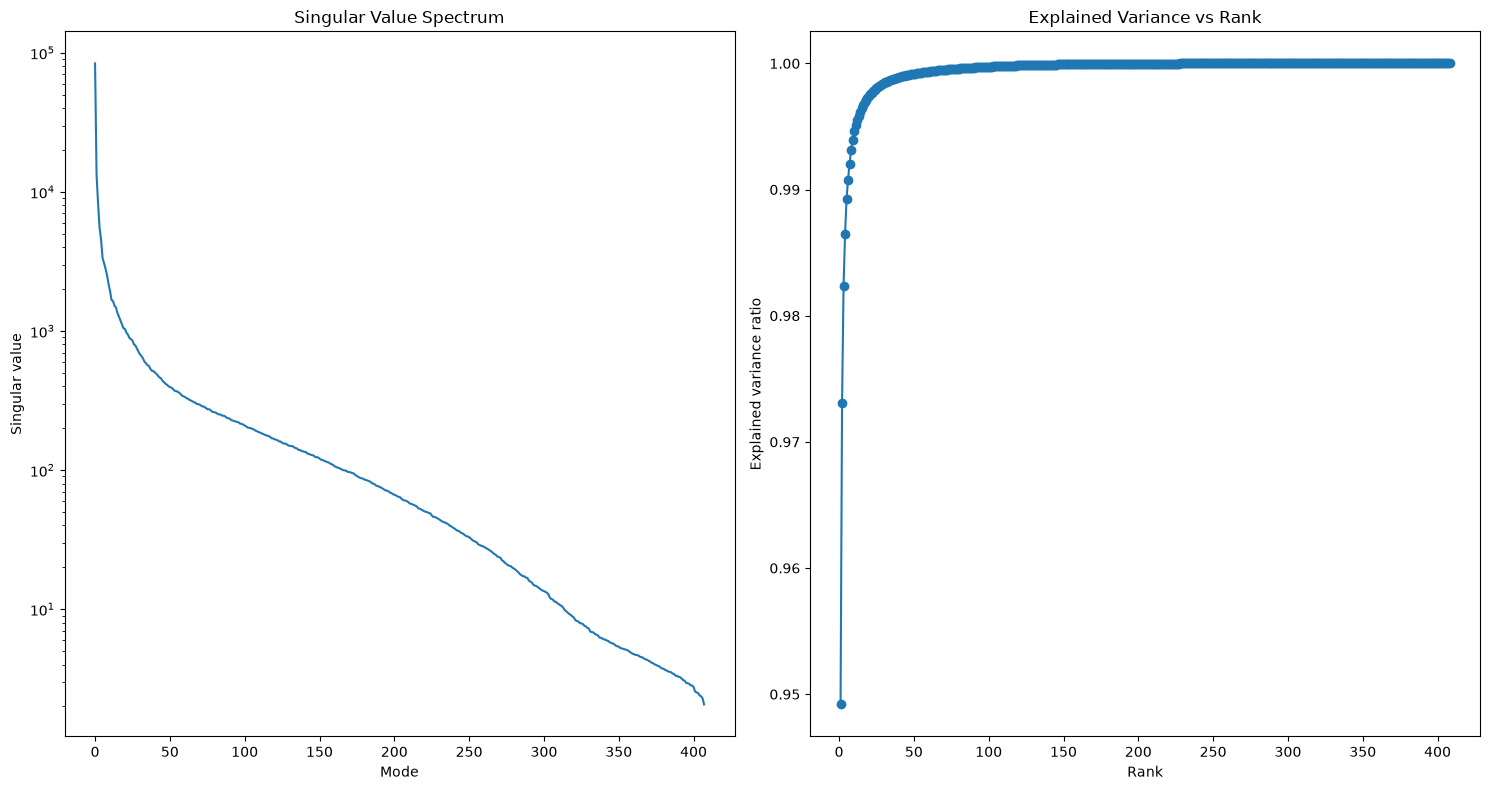

In [67]:
explained_variance = plot_svd_spectr_and_variance(S)

Low-rank reconstruction

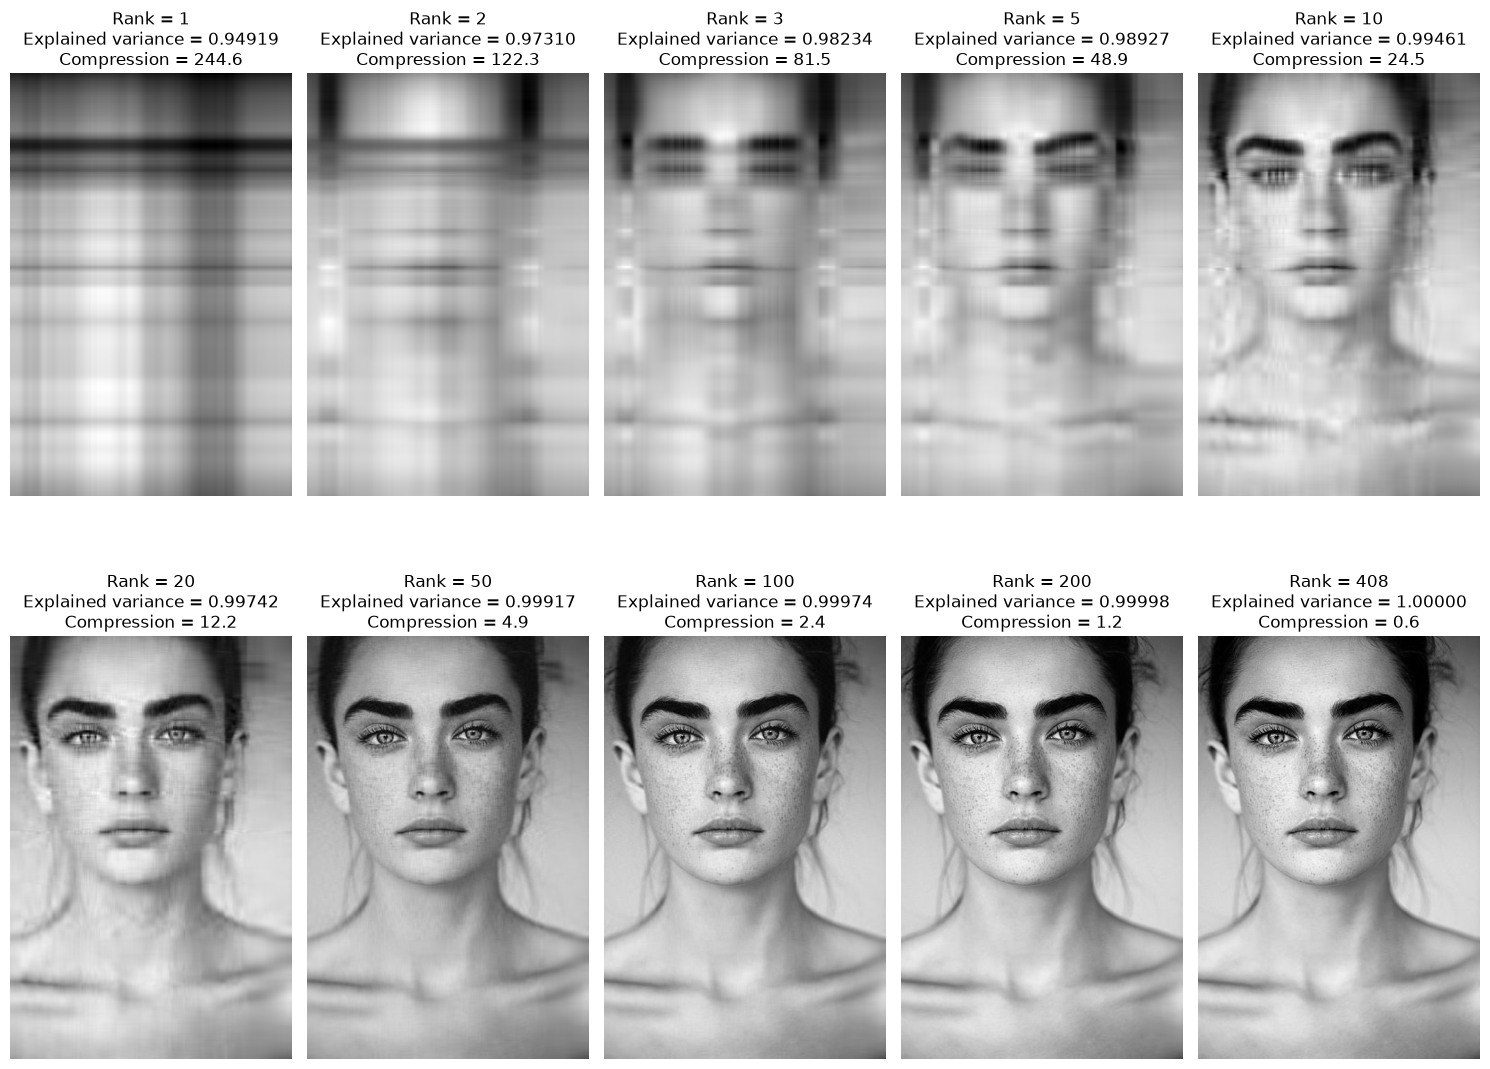

In [68]:
ranks = [1, 2, 3, 5, 10, 20, 50, 100, 200, len(S)]

low_rank_reconstruction(ranks, X_face, U, S, Vt, explained_variance)

### Engine

In [69]:
U, S, Vt = np.linalg.svd(X_engine, full_matrices=False)

singular value spectrum and explained variance

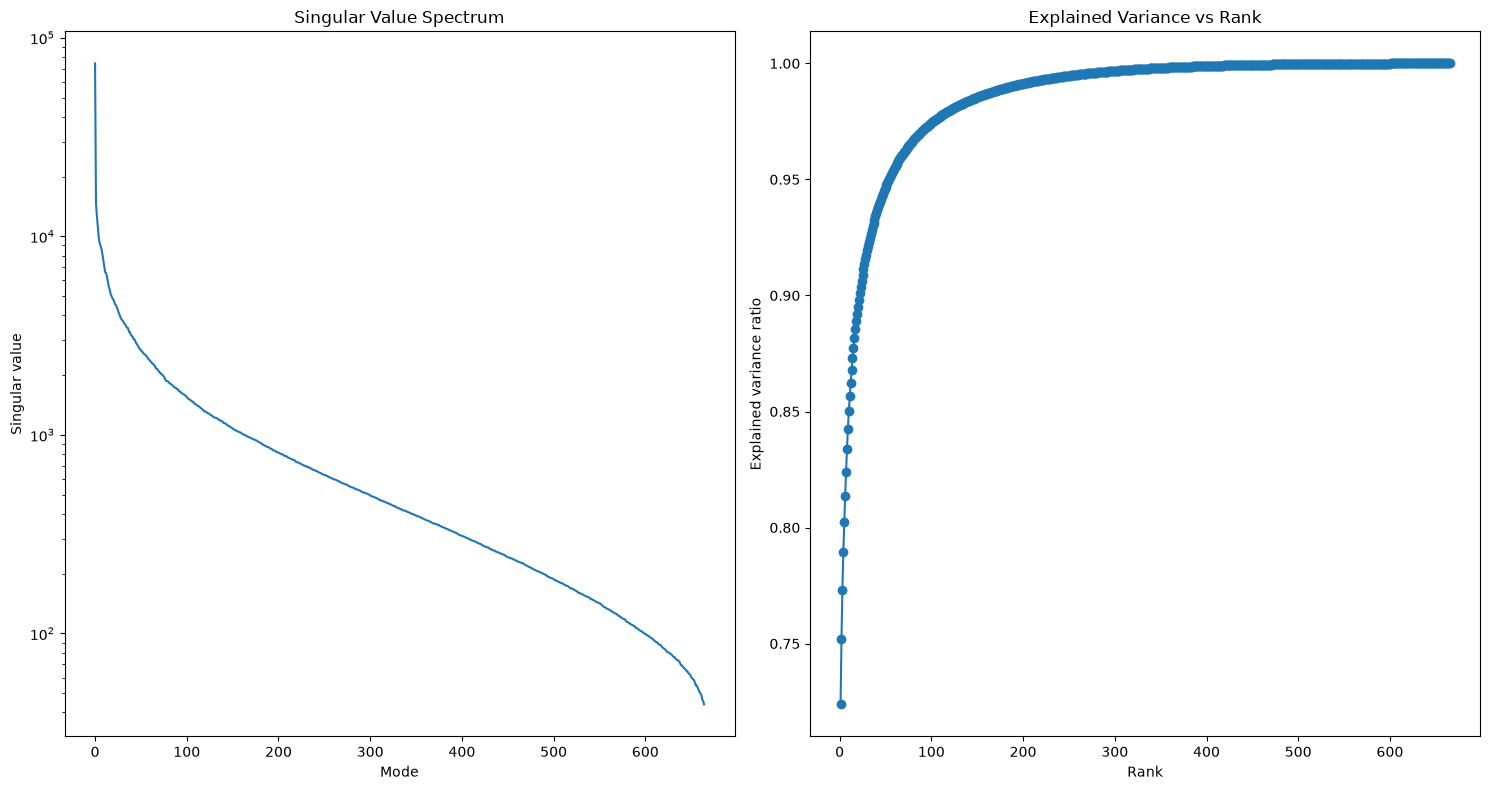

In [70]:
explained_variance = plot_svd_spectr_and_variance(S)

Low-rank reconstruction

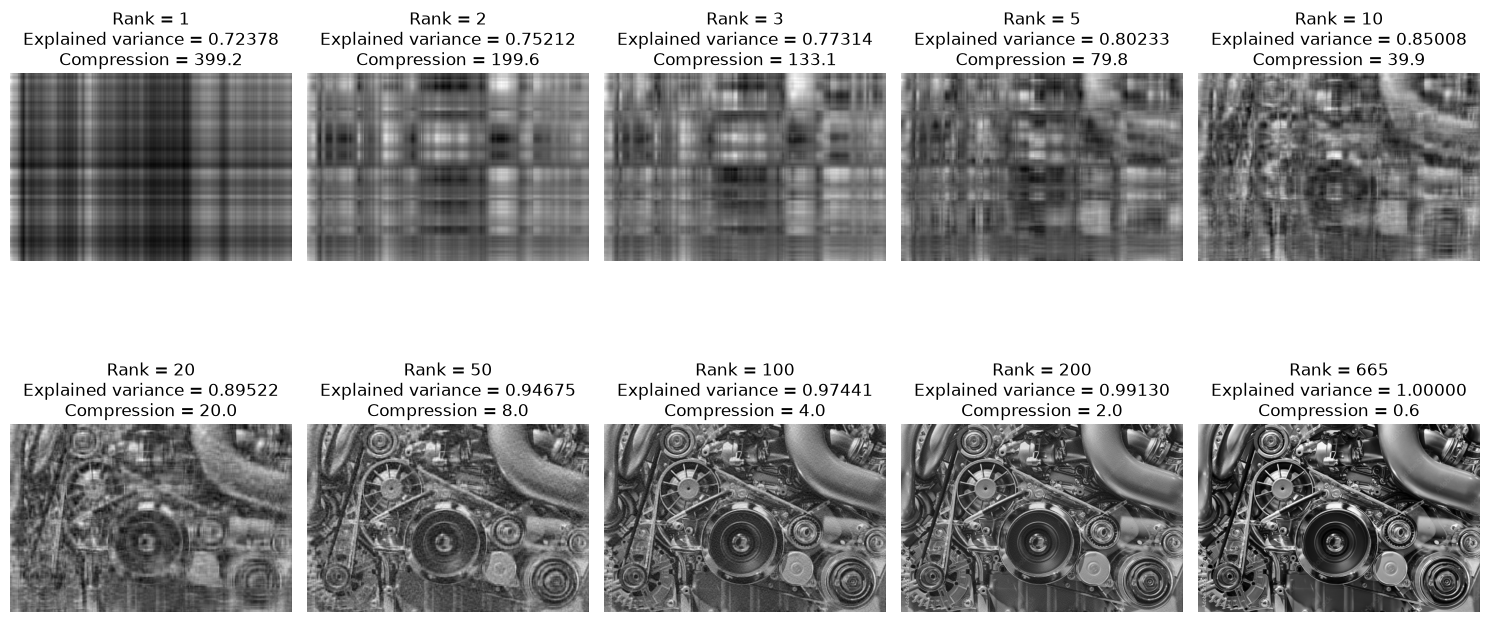

In [71]:
ranks = [1, 2, 3, 5, 10, 20, 50, 100, 200, len(S)]

low_rank_reconstruction(ranks, X_engine, U, S, Vt, explained_variance, size_y=8)

### Landscape

In [72]:
U, S, Vt = np.linalg.svd(X_landscape, full_matrices=False)

singular value spectrum and explained variance

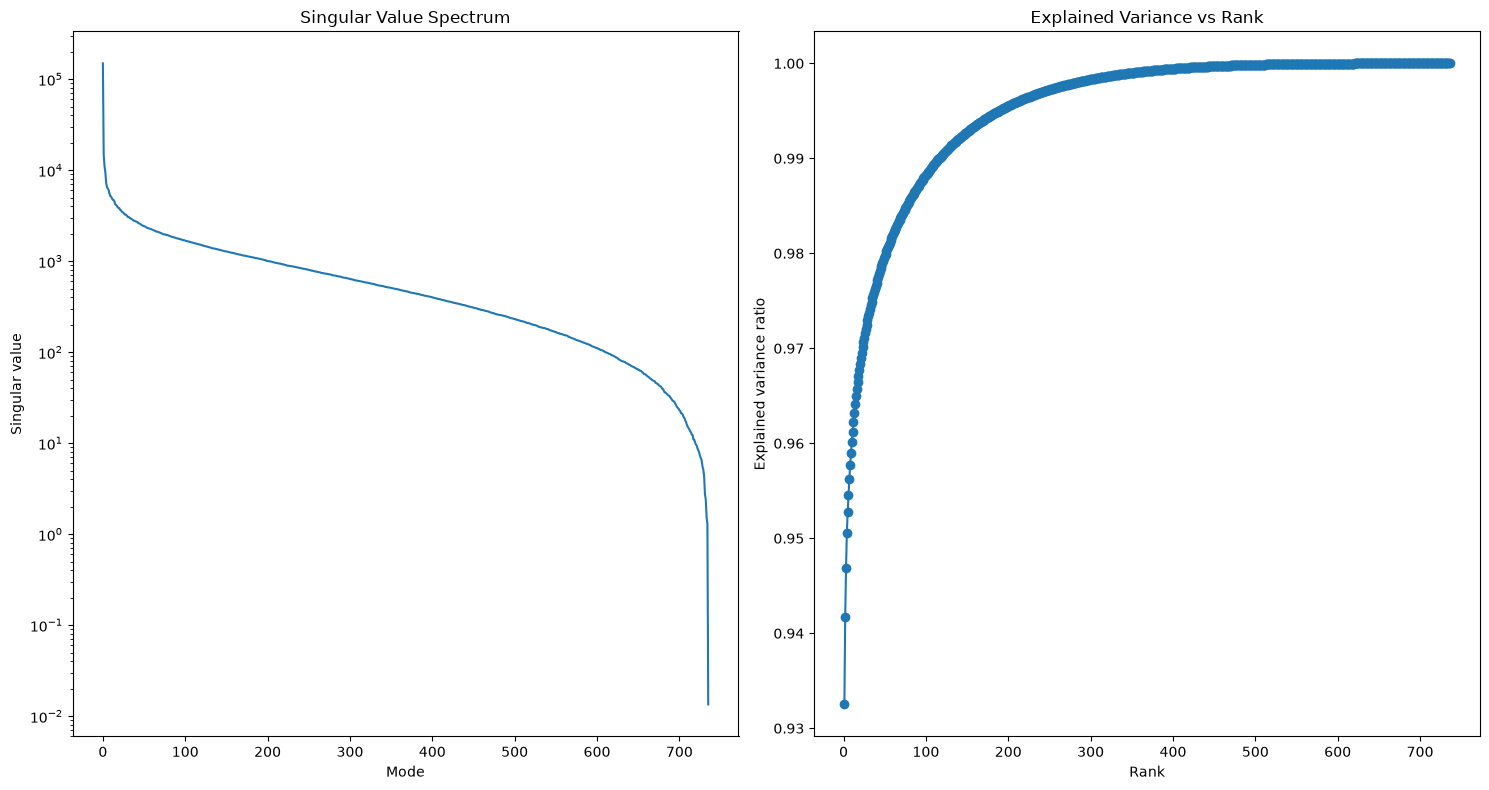

In [73]:
explained_variance = plot_svd_spectr_and_variance(S)

Low-rank reconstruction

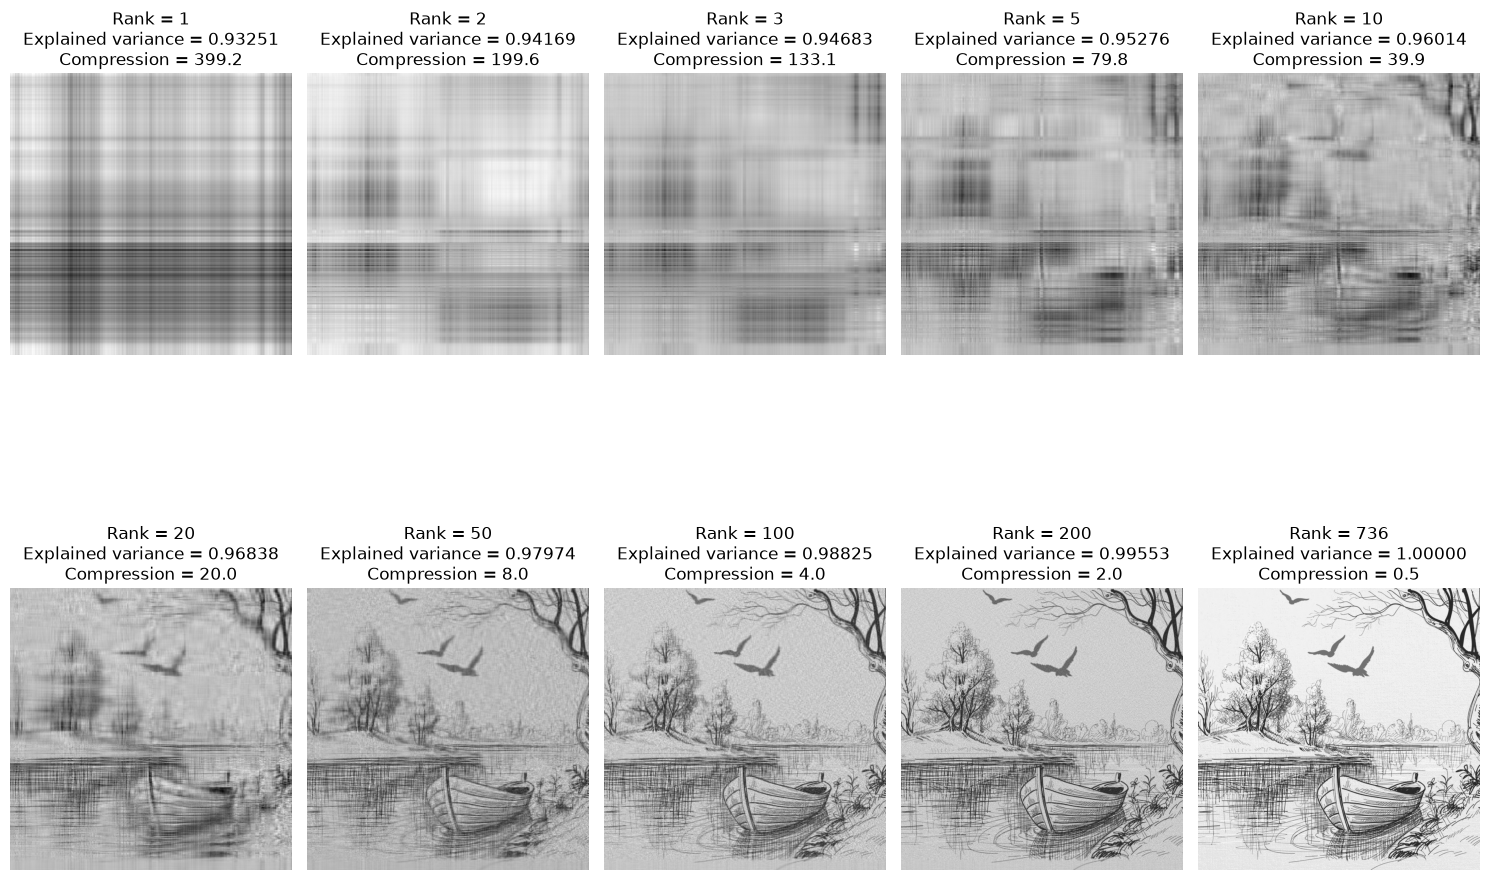

In [74]:
ranks = [1, 2, 3, 5, 10, 20, 50, 100, 200, len(S)]

low_rank_reconstruction(ranks, X_engine, U, S, Vt, explained_variance)

Although the first mode explains a large portion of the total energy, many more modes are required for a visually acceptable reconstruction. For the face and engine photographs, approximately 50–100 modes were needed to obtain reasonably good results. However, the pencil drawing showed noticeable darkening even at a rank of 200, indicating that its structure was less suitable for low-rank SVD compression.
